# BUCSS 2026
## AI Session Hands-On Part 2: Training different models for Task 2-1 Ghent

In this notebook you will:
- Load the training data
- Train AI models (Random Forest)
- Vary station subsets for training and validation

In [ ]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import random
import seaborn as sns
import time

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

#These are internal
import sys
sys.path.insert(0, "../scripts")
# print(sys.path)
from splitting_and_training import split_data, scale_data, train_model, feature_selection, prepare_station_training_data, explain_model, calc_importance
from plotting import obs_map, plot_scatter_and_residuals, plot_stats, plot_importance, plot_shap_summary

random.seed(42)  # define seed to create deterministic results by pseudo-randomness

In [2]:
city = "ghent"
target = "temp_diff"

# 1) Load data
df = pd.read_parquet(f"../dataframes_for_training/{city}_training.parquet")

hod = df["datetime_utc"].dt.hour
doy = df["datetime_utc"].dt.dayofyear
df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

# All Stations
print(f'Stations: {list(df["station_id"].unique())}')

# (the defined target) DeltaT
df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

df["datetime_utc"].min(), df["datetime_utc"].max(), df.columns

Stations: ['BEL_GNE_001', 'BEL_GNE_006', 'BEL_GNE_005', 'BEL_GNE_004', 'BEL_GNE_003', 'BEL_GNE_002']


(Timestamp('2016-07-01 01:00:00+0000', tz='UTC'),
 Timestamp('2023-10-12 06:00:00+0000', tz='UTC'),
 Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
        'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
        'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
        'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
        'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
        'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
        'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
        'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
        'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
        'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
        'doy_cos', 'temp_diff'],
       dtype='str'))

### Select a station subset to train on, keep remaining data as validation set

In [3]:
subset_options = {1:"random", 2:"manual"}

# VARY THIS PARAMETER TO SWITCH BETWEEN SELECTION STRATEGIES
selection_strategy = 1

# TODO: use split_data function
if selection_strategy == 1:
    # random selection
    stations = list(df["station_id"].unique())
    # VARY n TO CHANGE THE NUMBER OF STATIONS THAT SHOULD BE SELECTED FOR TRAINING
    n = 3
    train_station_subset = random.sample(stations, n)

elif selection_strategy == 2:
    # manual selection (not required to use, just as another option for you)
    # VARY STATION IDS
    # Ghent
    train_station_subset = ["BEL_GNE_001", "BEL_GNE_006", "BEL_GNE_005"]
else:
    print("NO SAMPLE SELECTED")
    train_station_subset = []


train_sample = df[df["station_id"].isin(train_station_subset)]
val_sample = df[~df["station_id"].isin(train_station_subset)]


display(train_sample)
display(val_sample)

,station_id,latitude,longitude,datetime_utc,air_temperature,bh_nearest,bh_buf50,bh_buf100,bh_buf250,bh_buf500,...,ssrd_deac,tp_deac,rh,wspd,t2m_corr,tod_sin,tod_cos,doy_sin,doy_cos,temp_diff
0,BEL_GNE_001,51.090,3.749,2016-07-01 01:00:00+00:00,17.1,0.0,0.000000,0.000000,0.047425,0.635946,...,0.0,9.238720e-07,86.885193,4.525703,16.196278,0.258819,9.659258e-01,-0.008607,-0.999963,0.903722
1,BEL_GNE_001,51.090,3.749,2016-07-01 02:00:00+00:00,16.8,0.0,0.000000,0.000000,0.047425,0.635946,...,0.0,1.327321e-05,86.067406,4.670997,16.679676,0.500000,8.660254e-01,-0.008607,-0.999963,0.120324
2,BEL_GNE_001,51.090,3.749,2016-07-01 03:00:00+00:00,16.7,0.0,0.000000,0.000000,0.047425,0.635946,...,0.0,2.698973e-05,85.446083,4.832330,16.978992,0.707107,7.071068e-01,-0.008607,-0.999963,-0.278992
3,BEL_GNE_001,51.090,3.749,2016-07-01 04:00:00+00:00,17.0,0.0,0.000000,0.000000,0.047425,0.635946,...,3007.0,6.176531e-06,84.777199,4.780536,17.015858,0.866025,5.000000e-01,-0.008607,-0.999963,-0.015858
4,BEL_GNE_001,51.090,3.749,2016-07-01 05:00:00+00:00,16.3,0.0,0.000000,0.000000,0.047425,0.635946,...,76370.0,8.568168e-07,83.871613,4.671044,17.062489,0.965926,2.588190e-01,-0.008607,-0.999963,-0.762489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366057,BEL_GNE_002,51.084,3.703,2023-10-12 02:00:00+00:00,15.8,0.0,1.790123,1.485804,1.482917,1.556150,...,0.0,5.074684e-04,88.116867,1.767234,16.087889,0.500000,8.660254e-01,-0.981306,0.192452,-0.287889
366058,BEL_GNE_002,51.084,3.703,2023-10-12 03:00:00+00:00,15.4,0.0,1.790123,1.485804,1.482917,1.556150,...,0.0,7.514730e-04,91.977348,2.209235,15.630857,0.707107,7.071068e-01,-0.981306,0.192452,-0.230857
366059,BEL_GNE_002,51.084,3.703,2023-10-12 04:00:00+00:00,15.2,0.0,1.790123,1.485804,1.482917,1.556150,...,0.0,4.902482e-04,92.354988,2.224110,15.541501,0.866025,5.000000e-01,-0.981306,0.192452,-0.341501
366060,BEL_GNE_002,51.084,3.703,2023-10-12 05:00:00+00:00,15.3,0.0,1.790123,1.485804,1.482917,1.556150,...,0.0,2.923086e-04,92.572227,2.272043,15.482419,0.965926,2.588190e-01,-0.981306,0.192452,-0.182419


,station_id,latitude,longitude,datetime_utc,air_temperature,bh_nearest,bh_buf50,bh_buf100,bh_buf250,bh_buf500,...,ssrd_deac,tp_deac,rh,wspd,t2m_corr,tod_sin,tod_cos,doy_sin,doy_cos,temp_diff
62620,BEL_GNE_006,50.980,3.816,2016-07-01 01:00:00+00:00,16.6,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,9.238720e-07,86.885193,4.525703,16.150778,0.258819,9.659258e-01,-0.008607,-0.999963,0.449222
62621,BEL_GNE_006,50.980,3.816,2016-07-01 02:00:00+00:00,16.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,1.327321e-05,86.067406,4.670997,16.634176,0.500000,8.660254e-01,-0.008607,-0.999963,-0.634176
62622,BEL_GNE_006,50.980,3.816,2016-07-01 03:00:00+00:00,16.5,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,2.698973e-05,85.446083,4.832330,16.933493,0.707107,7.071068e-01,-0.008607,-0.999963,-0.433493
62623,BEL_GNE_006,50.980,3.816,2016-07-01 04:00:00+00:00,16.5,0.0,0.000000,0.000000,0.000000,0.000000,...,3007.0,6.176531e-06,84.777199,4.780536,16.970358,0.866025,5.000000e-01,-0.008607,-0.999963,-0.470358
62624,BEL_GNE_006,50.980,3.816,2016-07-01 05:00:00+00:00,16.6,0.0,0.000000,0.000000,0.000000,0.000000,...,76370.0,8.568168e-07,83.871613,4.671044,17.016989,0.965926,2.588190e-01,-0.008607,-0.999963,-0.416989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251047,BEL_GNE_004,51.051,3.728,2023-10-12 02:00:00+00:00,16.1,0.0,6.617284,7.529968,7.573687,8.009943,...,0.0,5.074684e-04,88.116867,1.767234,16.053438,0.500000,8.660254e-01,-0.981306,0.192452,0.046562
251048,BEL_GNE_004,51.051,3.728,2023-10-12 03:00:00+00:00,15.8,0.0,6.617284,7.529968,7.573687,8.009943,...,0.0,7.514730e-04,91.977348,2.209235,15.596407,0.707107,7.071068e-01,-0.981306,0.192452,0.203593
251049,BEL_GNE_004,51.051,3.728,2023-10-12 04:00:00+00:00,15.5,0.0,6.617284,7.529968,7.573687,8.009943,...,0.0,4.902482e-04,92.354988,2.224110,15.507051,0.866025,5.000000e-01,-0.981306,0.192452,-0.007051
251050,BEL_GNE_004,51.051,3.728,2023-10-12 05:00:00+00:00,15.6,0.0,6.617284,7.529968,7.573687,8.009943,...,0.0,2.923086e-04,92.572227,2.272043,15.447969,0.965926,2.588190e-01,-0.981306,0.192452,0.152031


In [4]:
print("Training Sample")
display(train_sample.describe())
print("Validation Sample")
display(val_sample.describe())

Training Sample


,latitude,longitude,air_temperature,bh_nearest,bh_buf50,bh_buf100,bh_buf250,bh_buf500,bh_buf750,bh_buf1000,...,ssrd_deac,tp_deac,rh,wspd,t2m_corr,tod_sin,tod_cos,doy_sin,doy_cos,temp_diff
count,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,177630.000000,...,177630.000,1.776300e+05,177630.000000,177630.000000,177630.000000,177630.000000,1.776300e+05,177630.000000,177630.000000,177630.000000
mean,51.076893,3.727574,12.701515,1.729100,2.898823,2.462021,2.517122,2.606067,2.592139,2.565887,...,484278.875,8.817455e-05,77.832451,3.533090,11.922696,-0.001501,-8.232853e-04,-0.024600,-0.013378,0.778819
std,0.016040,0.019607,6.615541,2.717509,3.225464,2.762772,2.808765,2.397957,2.133365,1.952018,...,738146.625,3.038401e-04,14.675771,1.714263,6.646981,0.706951,7.072649e-01,0.709605,0.704047,1.247066
min,51.052000,3.703000,0.000000,0.000000,0.000000,0.000000,0.047425,0.635946,0.891594,1.111277,...,0.000,0.000000e+00,21.303194,0.026787,-10.155626,-1.000000,-1.000000e+00,-0.999991,-0.999963,-7.994969
25%,51.052000,3.703000,7.500000,0.000000,0.000000,0.000000,0.047425,0.635946,0.891594,1.111277,...,0.000,0.000000e+00,68.269035,2.288840,6.846144,-0.707107,-7.071068e-01,-0.729558,-0.708627,0.077690
50%,51.084000,3.732000,12.300000,0.000000,1.790123,1.485804,1.482917,1.556150,1.597736,1.543177,...,21918.000,4.276631e-07,81.182388,3.206496,11.623528,0.000000,-1.836970e-16,-0.060213,-0.030120,0.709093
75%,51.090000,3.749000,17.400000,6.000000,7.827160,6.690852,6.827639,6.325048,5.912143,5.620333,...,759114.000,2.701581e-05,89.733536,4.498959,16.773661,0.707107,7.071068e-01,0.693281,0.690173,1.406406
max,51.090000,3.749000,41.200000,6.000000,7.827160,6.690852,6.827639,6.325048,5.912143,5.620333,...,3210464.000,1.219387e-02,100.011253,15.101121,37.277576,1.000000,1.000000e+00,0.999991,1.000000,16.497093


Validation Sample


,latitude,longitude,air_temperature,bh_nearest,bh_buf50,bh_buf100,bh_buf250,bh_buf500,bh_buf750,bh_buf1000,...,ssrd_deac,tp_deac,rh,wspd,t2m_corr,tod_sin,tod_cos,doy_sin,doy_cos,temp_diff
count,188432.000000,188432.000000,188432.000000,188432.0,188432.000000,188432.000000,188432.000000,188432.000000,188432.000000,188432.000000,...,1.884320e+05,1.884320e+05,188432.000000,188432.000000,188432.000000,188432.000000,1.884320e+05,188432.000000,188432.000000,188432.000000
mean,51.022623,3.754843,12.706737,0.0,2.204755,2.685136,3.998746,4.074790,3.680695,3.370746,...,4.926599e+05,8.939585e-05,77.679718,3.536360,12.134289,-0.004147,-3.092731e-03,-0.031686,-0.033531,0.572448
std,0.030414,0.042810,6.572209,0.0,3.119070,3.431236,3.089996,3.257243,2.761060,2.456845,...,7.440198e+05,3.085041e-04,14.715023,1.709435,6.559985,0.706673,7.075248e-01,0.709551,0.703147,1.283694
min,50.980000,3.722000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,21.303194,0.026787,-10.200476,-1.000000,-1.000000e+00,-0.999991,-0.999963,-9.831197
25%,50.980000,3.722000,7.600000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,68.077850,2.297735,7.074088,-0.707107,-7.071068e-01,-0.741222,-0.732494,-0.092648
50%,51.036000,3.728000,12.300000,0.0,0.000000,0.520505,4.355941,4.151307,4.263855,4.172295,...,2.715800e+04,4.276632e-07,81.014877,3.213587,11.882318,0.000000,-1.836970e-16,-0.068802,-0.064508,0.579874
75%,51.051000,3.816000,17.400000,0.0,6.617284,7.529968,7.573687,8.009943,6.712709,5.875513,...,7.796560e+05,2.762675e-05,89.629944,4.501400,16.924829,0.707107,7.071068e-01,0.687053,0.664855,1.267130
max,51.051000,3.816000,39.900000,0.0,6.617284,7.529968,7.573687,8.009943,6.712709,5.875513,...,3.210464e+06,1.219387e-02,100.011253,15.101121,37.237274,1.000000,1.000000e+00,0.999991,1.000000,15.700476


Describe the train and validation set

In [5]:
print(f"LCZ classes in train set{train_sample['lcz_nearest'].unique()}")
print(f"LCZ classes in val set{val_sample['lcz_nearest'].unique()}")

LCZ classes in train set[8. 2. 6.]
LCZ classes in val set[14.  6.  2.]


Create Training and validation sets based on the selected station subset. The training set will consist of data from the chosen stations, while the validation set will include data from the remaining stations. This allows us to evaluate the model's performance on unseen data.

In [6]:
# TODO: use split_data function

def split_input_output(sample):    # drop any possible target variable from the training dataframe (X)
    target_col = sample["temp_diff"]
    # drop any possible target variable from the training dataframe (X)
    X = sample.drop(columns=["air_temperature", "temp_diff"]).copy()
    # drop station_id as we don't want strings in our predictors
    X = X.drop(columns=["station_id"]).copy()
    # Set y as the target column
    y = target_col
    return X, y

X_train, y_train = split_input_output(train_sample)
X_val, y_val = split_input_output(val_sample)

## Baselines and first look: Compute the RMSE on held-out stations of 
- Baseline 1: "The ideal case" where the model predicts no difference between observations and ERA5, i.e. ΔT = 0. (unrealistic, but useful for comparison).
- Baseline 2: "The average case", where the model predicts the training set average delta (instead of an actual prediction, the model just assumes the average delta of the training set for all validation samples).

Vary the station subset to see how the RMSE of the baselines changes.
> "Then look again at the static predictor values: do your six stations span a range at all?"

What do you observe?
Can the choice of station subset affect the RMSE of the baseline? Why or why not?

In [7]:
# Baseline 1: compute rmse on DeltaT = 0

# This is your "ideal" baseline - what RMSE would be if the model assumes perfect agreement of ERA5 and observations
prediction = np.zeros_like(y_val)
# Calculate RMSE: actual ΔT on held-out stations vs. difference of ERA5 and observations is 0 (ΔT = 0)
rmse_perfect = root_mean_squared_error(y_val, prediction)
print(f"RMSE for ΔT = 0 baseline: {rmse_perfect:.3f}°C")


# Baseline 2: compute rmse on mean DeltaT

# Calculate mean delta from training stations
mean_delta_train = y_train.mean()
# "Predict" this mean for all held-out stations
prediction = np.full(len(y_val), mean_delta_train)
# Calculate RMSE between actual delta and the assumed mean delta
rmse_mean = root_mean_squared_error(y_val, prediction)
print(f"RMSE for mean ΔT baseline: {rmse_mean:.3f}°C")

RMSE for ΔT = 0 baseline: 1.406°C
RMSE for mean ΔT baseline: 1.300°C


# First Model run: Random Forest with Leave-One-Out Cross-Validation (LOOCV)

Note: This approach does **not** use the station subset selection above, but rather uses all stations for training and validation.
The RMSE is computed for each station by leaving it out of the training set and using it as the validation set.

IF you just started: note that the dataset is reduced to a single year. Don't change anything for now, so skip this part and move on to the next cell. You will come back to this section later.

IF you finish early: Modify the dataframe

- limit available time of observation data to a year
- drop static predictors

_NOTE_ You can also test different variants of timerange and static predictor availability
- e.g. 2019 vs 2021 with or without static predictors
- 2019 but only some static predictors available, e.g. only lcz, or dtm+bh+tcd
vary as you wish
do you have certain assumptions about the behaviour of certain years / predictors?

In [8]:
if True:
    # set to a certain time range
    start_time = datetime.datetime(2019,1,1,0, tzinfo=datetime.UTC)
    end_time = datetime.datetime(2020,1,1,0, tzinfo=datetime.UTC)
    df = df[(df["datetime_utc"]>=start_time) & (df["datetime_utc"] < end_time)]
    print(df["datetime_utc"].min(), df["datetime_utc"].max())

# SET TO TRUE IF YOU FINISH EARLY
if False:
    # drop static predictors
    static_columns = ["latitude", "longitude"]
    for col in df.columns:
        if "imp" in col:
            static_columns.append(col)
        if "dtm" in col:
            static_columns.append(col)
        if "lcz" in col.lower():
            static_columns.append(col)
        if "bh" in col:
            static_columns.append(col)
        if "tcd" in col:
            static_columns.append(col)
    df = df.drop(columns=static_columns)
    print(df.columns)

2019-01-01 00:00:00+00:00 2019-12-31 23:00:00+00:00


In [9]:
# Get unique stations
stations = df['station_id'].unique()
print(f"Found {len(stations)} stations: {stations}")

# Store results
results = []

# Leave-one-station-out cross-validation
for test_station in stations:
    start_time = time.time()
    print(f"\nProcessing test station: {test_station}")

    # Split data: train on all stations EXCEPT test_station
    X_train_rf = df[df['station_id'] != test_station].copy()
    X_test_rf = df[df['station_id'] == test_station].copy()

    # drop datetime attribute as this cannot be handled by the RandomForestRegressor
    # keep in mind that the time of day and day of year are captured in cyclical encoded variables in the beginning
    y_train_rf = X_train_rf['temp_diff']
    X_train_rf = X_train_rf.drop(columns=['station_id', 'temp_diff', 'air_temperature', 'datetime_utc'])
    y_test_rf = X_test_rf['temp_diff']
    X_test_rf = X_test_rf.drop(columns=['station_id', 'temp_diff', 'air_temperature', 'datetime_utc'])

    # Train Random Forest with default settings
    model = RandomForestRegressor(random_state=42)  # as set initally!
    model.fit(X_train_rf, y_train_rf)

    # Predict on test station
    y_pred = model.predict(X_test_rf)

    # Calculate RMSE
    rmse = root_mean_squared_error(y_test_rf, y_pred)
    results.append({
        'test_station': test_station,
        'rmse': rmse,
        'n_train_samples': len(X_train_rf),
        'n_test_samples': len(X_test_rf)
    })

    print(f"  Train samples: {len(X_train_rf)}")
    print(f"  Test samples: {len(X_test_rf)}")
    print(f"  RMSE: {rmse:.3f}°C [baselines: 1: {rmse_perfect}, 2: {rmse_mean}]")
    print(f"  Elapsed time: {datetime.timedelta(seconds=time.time()-start_time)}")


# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL RESULTS:")
print(results_df.to_string(index=False))

Found 6 stations: <ArrowStringArray>
['BEL_GNE_001', 'BEL_GNE_006', 'BEL_GNE_005', 'BEL_GNE_004', 'BEL_GNE_003',
 'BEL_GNE_002']
Length: 6, dtype: str

Processing test station: BEL_GNE_001
  Train samples: 43444
  Test samples: 8628
  RMSE: 0.625°C [baselines: 1: 1.405545551495526, 2: 1.3001731720788476]
  Elapsed time: 0:01:38.195991

Processing test station: BEL_GNE_006
  Train samples: 43555
  Test samples: 8517
  RMSE: 1.290°C [baselines: 1: 1.405545551495526, 2: 1.3001731720788476]
  Elapsed time: 0:01:47.896097

Processing test station: BEL_GNE_005
  Train samples: 43313
  Test samples: 8759
  RMSE: 0.618°C [baselines: 1: 1.405545551495526, 2: 1.3001731720788476]
  Elapsed time: 0:01:42.916795

Processing test station: BEL_GNE_004
  Train samples: 43422
  Test samples: 8650
  RMSE: 0.586°C [baselines: 1: 1.405545551495526, 2: 1.3001731720788476]
  Elapsed time: 0:02:02.272706

Processing test station: BEL_GNE_003
  Train samples: 43313
  Test samples: 8759
  RMSE: 0.542°C [baseli

Visualize LOOCV results for each station, showing the RMSE for each station when it is left out of the training set. This will help us understand how well the model generalizes to unseen stations.

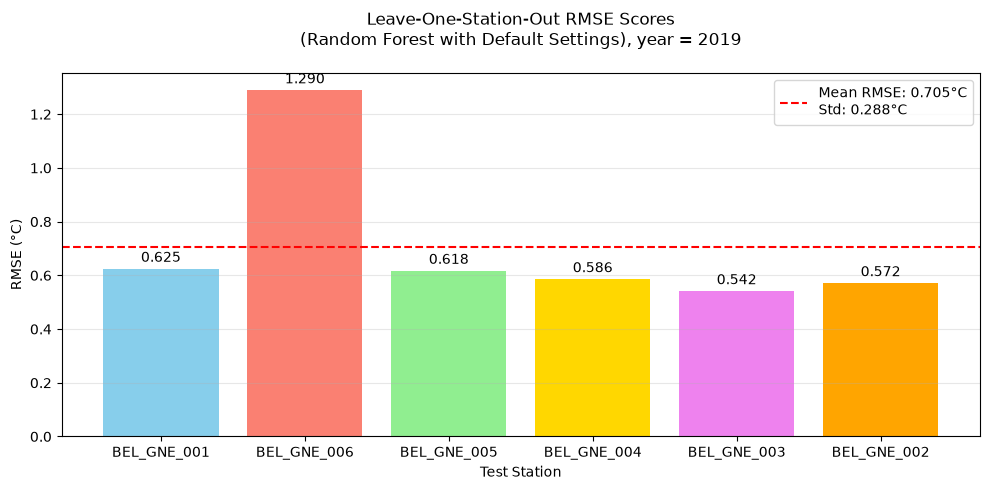


SPREAD ANALYSIS:
Mean RMSE across folds: 0.705°C
Standard deviation: 0.288°C
Range (max-min): 0.748°C (between stations BEL_GNE_006 and BEL_GNE_003)
Coefficient of variation (Std/Mean): 40.82%

Interpretation:
High variability - model performance depends heavily on which station is left out (standard deviation more than +/- 30 % around mean)


In [10]:
# Visualize the six fold scores
plt.figure(figsize=(10, 5))

# Bar plot with error bars (though we have exact values)
plt.bar(results_df['test_station'], results_df['rmse'],
        color=['skyblue', 'salmon', 'lightgreen', 'gold', 'violet', 'orange'])

# Add value labels on bars
for i, v in enumerate(results_df['rmse']):
    plt.text(i, v + 0.01*max(results_df['rmse']),
             f"{v:.3f}", ha='center', va='bottom')

plt.title(f'Leave-One-Station-Out RMSE Scores\n(Random Forest with Default Settings), year = {df["datetime_utc"].min().year}', pad=20)
plt.ylabel('RMSE (°C)')
plt.xlabel('Test Station')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add mean and spread
mean_rmse = results_df['rmse'].mean()
std_rmse = results_df['rmse'].std()
plt.axhline(y=mean_rmse, color='red', linestyle='--',
            label=f'Mean RMSE: {mean_rmse:.3f}°C\nStd: {std_rmse:.3f}°C')
plt.legend()

plt.show()

# Print spread analysis
print("\n" + "="*50)
print("SPREAD ANALYSIS:")
print(f"Mean RMSE across folds: {mean_rmse:.3f}°C")
print(f"Standard deviation: {std_rmse:.3f}°C")
print(f"Range (max-min): {results_df['rmse'].max() - results_df['rmse'].min():.3f}°C "\
      f"(between stations {results_df[results_df['rmse'] == results_df['rmse'].max()].iloc[0]['test_station']} and {results_df[results_df['rmse'] == results_df['rmse'].min()].iloc[0]['test_station']})")
print(f"Coefficient of variation (Std/Mean): {std_rmse/mean_rmse:.2%}")

print("\nInterpretation:")
if std_rmse < 0.1 * mean_rmse:
    print("Low variability - model performs consistently across stations (standard deviation max. +/- 10 % around mean)")
elif std_rmse < 0.3 * mean_rmse:
    print("Moderate variability - some station-specific performance differences (standard deviation max. +/- 30 % around mean)")
else:
    print("High variability - model performance depends heavily on which station is left out (standard deviation more than +/- 30 % around mean)")

## If there is time left in the first block, repeat this `^` analysis for a different year.

# Block 2: Main Experiment

Ghent: Vary the number of training stations: 2, 3, 4, 5. For each level draw the training stations at random, test on a held-out station, and repeat with at least ten different draws. The spread across draws matters as much as the mean.

In [11]:
results = []

print(f"Baseline 1 (ΔT=0): {rmse_perfect:.3f}\nBaseline 2 (mean ΔT): {rmse_mean:.3f}")


# You could use a for loop (e.g. like the one suggested below), but beware that each loop takes ~5 minutes.
# for n in [2, 3, 4, 5]:

n = 2
print(f"N stations {n}")
start_time=time.time()

# VARY NUMBER OF DRAWS  
n_draws = 10

for draw in range(n_draws):

    # Use selection strategy 1 from above to create a random subset for training
    stations = list(df["station_id"].unique())
    train_station_subset = random.sample(stations, n)
    train_sample = df[df["station_id"].isin(train_station_subset)]

    # hold one of the station out, that is not in the train set
    not_train_sample = df[~df["station_id"].isin(train_station_subset)]
    not_train_stations = list(not_train_sample["station_id"].unique())
    held_out_station = random.sample(not_train_stations, 1)[0]
    held_out_station_sample = not_train_sample[not_train_sample["station_id"] == held_out_station]

    # hold-out-station validation (similar to above LOOCV process)
    
    X_train_rf = train_sample.drop(columns=['station_id', 'temp_diff', 'air_temperature', 'datetime_utc'])
    y_train_rf = train_sample['temp_diff']

    X_test_rf = held_out_station_sample.drop(columns=['station_id', 'temp_diff', 'air_temperature', 'datetime_utc'])
    y_test_rf = held_out_station_sample['temp_diff']

    # Train Random Forest with default settings
    model = RandomForestRegressor(random_state=42)  # as set initally!
    model.fit(X_train_rf, y_train_rf)

    # Predict on hold-out station
    y_pred = model.predict(X_test_rf)

    # Calculate RMSE
    rmse = root_mean_squared_error(y_test_rf, y_pred)
    results.append({
        'n_stations': len(train_station_subset),
        'test_station': held_out_station,
        'rmse': rmse,
        'n_train_samples': len(X_train_rf),
        'n_test_samples': len(X_test_rf)
    })
print(f"Elapsed time: {datetime.timedelta(seconds=time.time() - start_time)}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL RESULTS:")
print(results_df.to_string(index=False))
results_df.to_csv(f"results_randomforest_{n}_stations.csv")

Baseline 1 (ΔT=0): 1.406
Baseline 2 (mean ΔT): 1.300
N stations 2
Elapsed time: 0:04:53.688430

FINAL RESULTS:
 n_stations test_station     rmse  n_train_samples  n_test_samples
          2  BEL_GNE_006 1.160096            17518            8517
          2  BEL_GNE_001 0.947757            17276            8628
          2  BEL_GNE_001 0.480121            17518            8628
          2  BEL_GNE_001 0.580640            17409            8628
          2  BEL_GNE_005 0.577303            17387            8759
          2  BEL_GNE_001 0.512935            17276            8628
          2  BEL_GNE_002 0.674241            17276            8759
          2  BEL_GNE_003 0.600932            17167            8759
          2  BEL_GNE_002 0.668785            17145            8759
          2  BEL_GNE_006 1.160096            17518            8517


<Axes: title={'center': 'N_stations: 2'}>

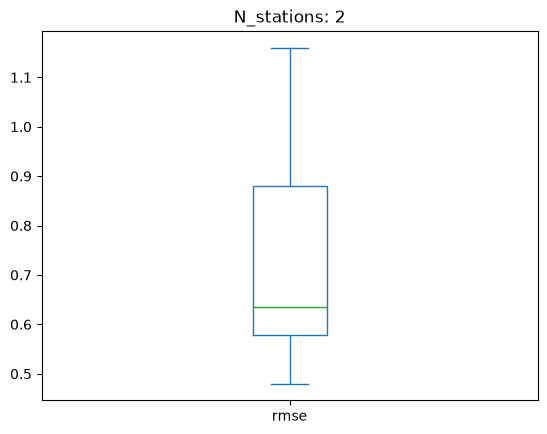

In [12]:
results_df["rmse"].plot.box(title=f"N_stations: {list(results_df['n_stations'].unique())[0]}")